# Modélisation

## Importation et demarrage spark

In [69]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, when, percentile_approx
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import PipelineModel


sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#3498db', '#e74c3c']

spark = (
    SparkSession.builder
    .appName('04_modelisation_immobilier')
    .master('local[*]')
    .config('spark.ui.enabled', 'false')
    .config('spark.sql.shuffle.partitions', '8')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')
print('Spark démarré, version:', spark.version)

Spark démarré, version: 4.1.1


In [2]:
##  1. Chargement des données

In [3]:
df = spark.read.parquet('../data/clean')

In [4]:
df.count()

5336

## Analyse exploratoire - Variable surface

In [5]:
df.select('surface').summary().show()

+-------+-----------------+
|summary|          surface|
+-------+-----------------+
|  count|             5336|
|   mean|81.92859820089954|
| stddev|55.84448515472042|
|    min|              5.0|
|    25%|             47.0|
|    50%|             70.0|
|    75%|            101.0|
|    max|           1233.0|
+-------+-----------------+



In [6]:
# Skewness et kurtosis
stats_surface = df.select(
    F.skewness('surface').alias('skewness'),
    F.kurtosis('surface').alias('kurtosis')
).collect()[0]

print(f"Skewness (asymétrie) : {stats_surface['skewness']:.4f}")
print(f"Kurtosis (aplatissement) : {stats_surface['kurtosis']:.4f}")

Skewness (asymétrie) : 3.9755
Kurtosis (aplatissement) : 47.5261


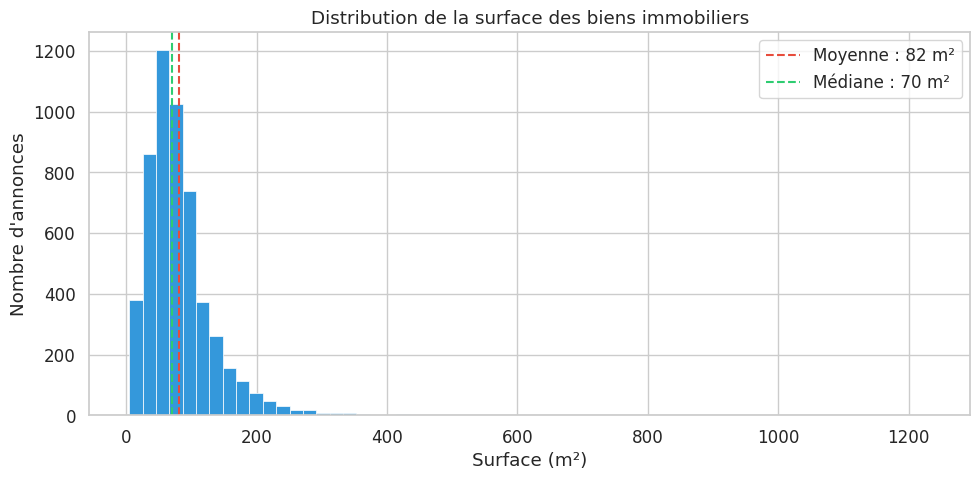

In [7]:
surface_pd = df.select('surface').dropna().toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(surface_pd['surface'], bins=60, color='#3498db', edgecolor='white', linewidth=0.5)

mean_val   = surface_pd['surface'].mean()
median_val = surface_pd['surface'].median()

ax.axvline(mean_val,   color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Moyenne : {mean_val:.0f} m²')
ax.axvline(median_val, color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Médiane : {median_val:.0f} m²')

ax.set_xlabel('Surface (m²)')
ax.set_ylabel('Nombre d\'annonces')
ax.set_title('Distribution de la surface des biens immobiliers')
ax.legend()
plt.tight_layout()
plt.show()

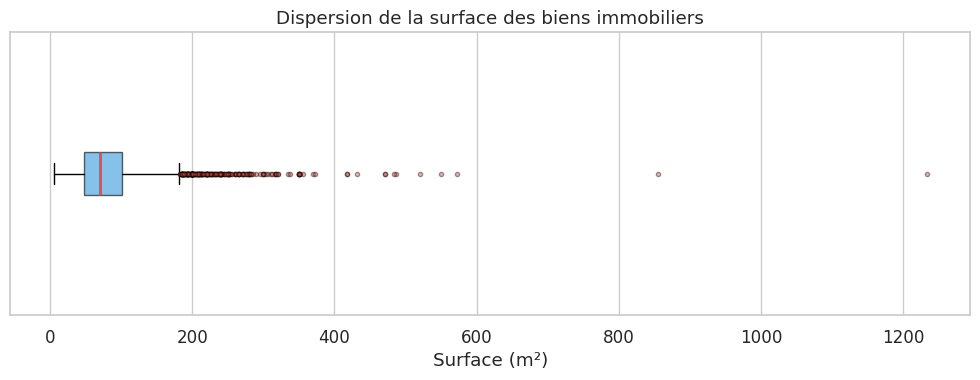

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(surface_pd['surface'].dropna(), vert=False, patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6),
           medianprops=dict(color='#e74c3c', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))

ax.set_xlabel('Surface (m²)')
ax.set_title('Dispersion de la surface des biens immobiliers')
ax.yaxis.set_visible(False)
plt.tight_layout()
plt.show()

- On voit que la plupart des biens sont dans la zone 47m² à 101m², nous avons quelques biens très grandes qui tirent la moyenne vers la haut, cela montre que la distribution n'est pas symetrique on a un etalement vers la droite. 
- Le minimum parait bizzare 5m2 avec le type de bien qu'on à. nous allons verifier et supprimer si c'est incoherent. 

In [9]:
df.select('surface', 'type_bien', 'prix').orderBy('surface').show(30, truncate=False)

+-------+-----------+--------+
|surface|type_bien  |prix    |
+-------+-----------+--------+
|5.0    |appartement|47000.0 |
|7.0    |appartement|100000.0|
|7.0    |appartement|70000.0 |
|7.0    |appartement|69500.0 |
|7.0    |appartement|55000.0 |
|8.0    |studio     |80000.0 |
|8.0    |studio     |133000.0|
|8.0    |appartement|109900.0|
|8.0    |appartement|89900.0 |
|8.0    |studio     |222000.0|
|8.0    |appartement|94000.0 |
|9.0    |appartement|53000.0 |
|9.0    |appartement|99000.0 |
|9.0    |appartement|70000.0 |
|9.0    |studio     |80000.0 |
|9.0    |appartement|88000.0 |
|9.0    |appartement|87000.0 |
|9.0    |appartement|120000.0|
|9.0    |appartement|135000.0|
|10.0   |studio     |105000.0|
|10.0   |appartement|180000.0|
|10.0   |appartement|105000.0|
|11.0   |appartement|75000.0 |
|11.0   |appartement|17000.0 |
|11.0   |studio     |133000.0|
|11.0   |appartement|99000.0 |
|11.0   |studio     |134000.0|
|11.0   |studio     |140000.0|
|11.0   |appartement|130000.0|
|12.0   

On voit des biens avec des surfaces très petites, entre 5 m² et 12 m². Ces valeurs sont bizarres par rapport au reste des annonces. Ce n’est pas forcément faux, mais ça peut venir d’une erreur ou d’un bien très particulier. Comme ça peut fausser le modèle, on décide de ne pas les garder dans le premier jeu de données pour le machine learning

In [10]:
df = df.filter(F.col("surface") >= 12)

## Analyse exploratoire - Variable prix

In [11]:
df.select('prix').summary().show()

+-------+------------------+
|summary|              prix|
+-------+------------------+
|  count|              5307|
|   mean|446981.38364424347|
| stddev| 625895.4354420466|
|    min|            9000.0|
|    25%|          207990.0|
|    50%|          320000.0|
|    75%|          530000.0|
|    max|             3.2E7|
+-------+------------------+



In [12]:
stats_prix = df.select(F.skewness('prix').alias('skewness'), F.kurtosis('prix').alias('kurtosis')).collect()[0]
print(f"Skewness : {stats_prix['skewness']:.4f}")
print(f"Kurtosis : {stats_prix['kurtosis']:.4f}")

Skewness : 27.1950
Kurtosis : 1255.6167


In [13]:
df.select('prix', 'surface', 'type_bien', 'ville', 'url_annonce').orderBy('prix').show(15, truncate=False)

+-------+-------+-----------+---------+-------------------------------------------------------------------------------------------------------------------------------------+
|prix   |surface|type_bien  |ville    |url_annonce                                                                                                                          |
+-------+-------+-----------+---------+-------------------------------------------------------------------------------------------------------------------------------------+
|9000.0 |178.0  |maison     |Paris    |https://www.leboncoin.fr/ad/ventes_immobilieres/2984155147                                                                           |
|19900.0|115.0  |maison     |Paris    |https://www.leboncoin.fr/ad/ventes_immobilieres/3175354865                                                                           |
|20000.0|60.0   |appartement|Paris    |https://www.leboncoin.fr/ad/ventes_immobilieres/3166184015                                 

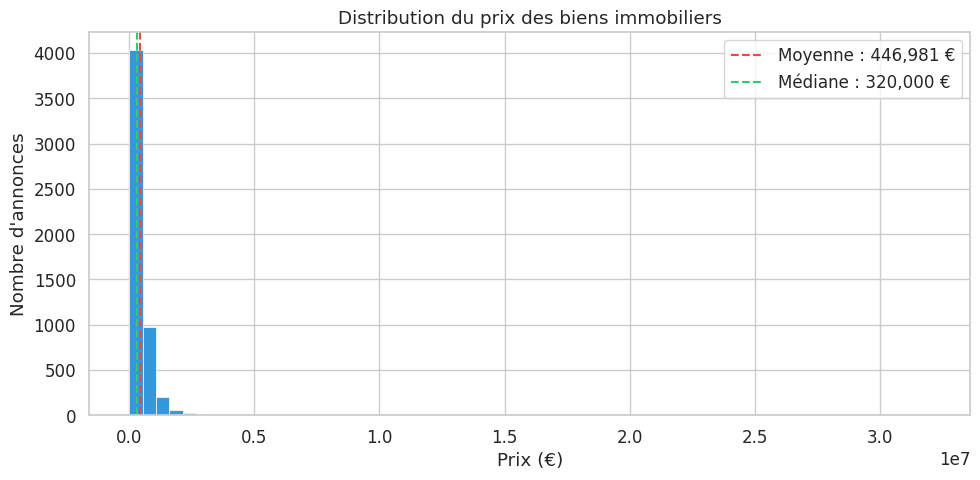

In [14]:
prix_pd = df.select('prix').dropna().toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(prix_pd['prix'], bins=60, color='#3498db', edgecolor='white', linewidth=0.5)
mean_val = prix_pd['prix'].mean()
median_val = prix_pd['prix'].median()
ax.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Moyenne : {mean_val:,.0f} €')
ax.axvline(median_val, color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Médiane : {median_val:,.0f} €')
ax.set_xlabel('Prix (€)')
ax.set_ylabel("Nombre d'annonces")
ax.set_title('Distribution du prix des biens immobiliers')
ax.legend()
plt.tight_layout()
plt.show()

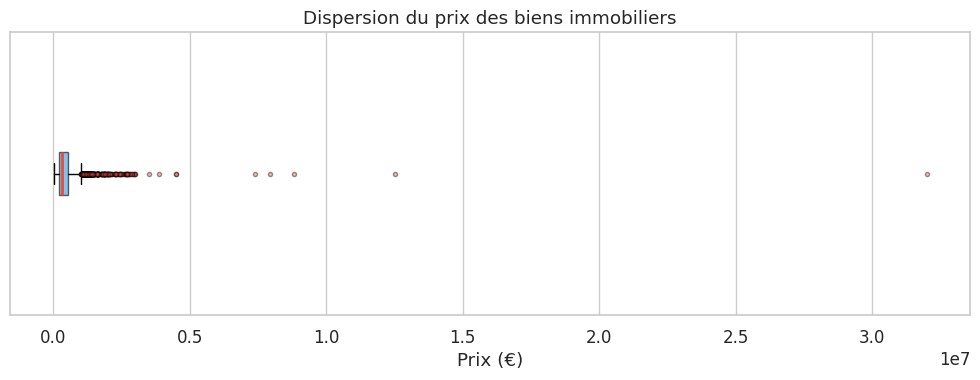

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(prix_pd['prix'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6), medianprops=dict(color='#e74c3c', linewidth=2), flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))
ax.set_xlabel('Prix (€)')
ax.set_title('Dispersion du prix des biens immobiliers')
ax.yaxis.set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
df_analyse = df.withColumn('tranche_surface', F.when(col('surface') < 30, '< 30m²').when(col('surface') < 50, '30-50m²').when(col('surface') < 80, '50-80m²').when(col('surface') < 120, '80-120m²').when(col('surface') < 200, '120-200m²').otherwise('> 200m²'))

df_analyse.groupBy('type_bien', 'tranche_surface').agg(F.count('prix').alias('nb_annonces'), F.round(F.median('prix'), 0).alias('prix_median'), F.round(F.mean('prix'), 0).alias('prix_moyen')).orderBy('type_bien', 'tranche_surface').show(50, truncate=False)

+-----------+---------------+-----------+-----------+----------+
|type_bien  |tranche_surface|nb_annonces|prix_median|prix_moyen|
+-----------+---------------+-----------+-----------+----------+
|appartement|120-200m²      |295        |700000.0   |998270.0  |
|appartement|30-50m²        |852        |197475.0   |245292.0  |
|appartement|50-80m²        |1561       |265000.0   |321829.0  |
|appartement|80-120m²       |967        |415000.0   |514626.0  |
|appartement|< 30m²         |267        |135000.0   |160332.0  |
|appartement|> 200m²        |39         |1190000.0  |2609874.0 |
|duplex     |120-200m²      |31         |745500.0   |873354.0  |
|duplex     |30-50m²        |23         |192000.0   |222889.0  |
|duplex     |50-80m²        |53         |287000.0   |351011.0  |
|duplex     |80-120m²       |69         |430000.0   |541384.0  |
|duplex     |< 30m²         |3          |238000.0   |250667.0  |
|duplex     |> 200m²        |5          |995000.0   |1729800.0 |
|immeuble   |120-200m²   

- La moyenne est de 446981 € , elle est beaucoup plus grande que la médiane. La majorité des biens a un prix situé entre 208 000 € et 530 000 €.
- Nous avons beaucoup d'incoherence sur les prix, on retire les biens avec une surface inférieure à 12 m², un prix inférieur à 80 000 € ou un prix au m² inférieur à 1 000 €.

In [17]:
df = df.withColumn("prix_m2", F.col("prix") / F.col("surface"))

df = df.filter(
    (F.col("surface") >= 12) &
    (F.col("prix") >= 80000) &
    (F.col("prix_m2") >= 1000)
)

## Analyse exploratoire - Variable nombres de chambres

In [18]:
total = df.count()
non_null = df.filter(F.col('nb_chambres').isNotNull()).count()
print(f"Total : {total} | Renseigné : {non_null} | Null : {total - non_null} ({(total - non_null)/total*100:.1f}%)")

Total : 5209 | Renseigné : 4695 | Null : 514 (9.9%)


In [19]:
df.groupBy('type_bien').agg(F.count('nb_chambres').alias('renseigné'), F.count('*').alias('total')).withColumn('taux_null_%', F.round((1 - F.col('renseigné')/F.col('total'))*100, 1)).orderBy(F.desc('total')).show(truncate=False)

+-----------+---------+-----+-----------+
|type_bien  |renseigné|total|taux_null_%|
+-----------+---------+-----+-----------+
|appartement|3639     |3932 |7.5        |
|maison     |778      |812  |4.2        |
|studio     |53       |218  |75.7       |
|duplex     |181      |184  |1.6        |
|loft       |38       |42   |9.5        |
|immeuble   |6        |21   |71.4       |
+-----------+---------+-----+-----------+



In [20]:
df.filter(F.col('nb_chambres').isNotNull()).groupBy('nb_chambres').count().orderBy('nb_chambres').show()

+-----------+-----+
|nb_chambres|count|
+-----------+-----+
|          1| 1279|
|          2| 1586|
|          3| 1137|
|          4|  468|
|          5|  162|
|          6|   45|
|          7|   16|
|          8|    1|
|         11|    1|
+-----------+-----+



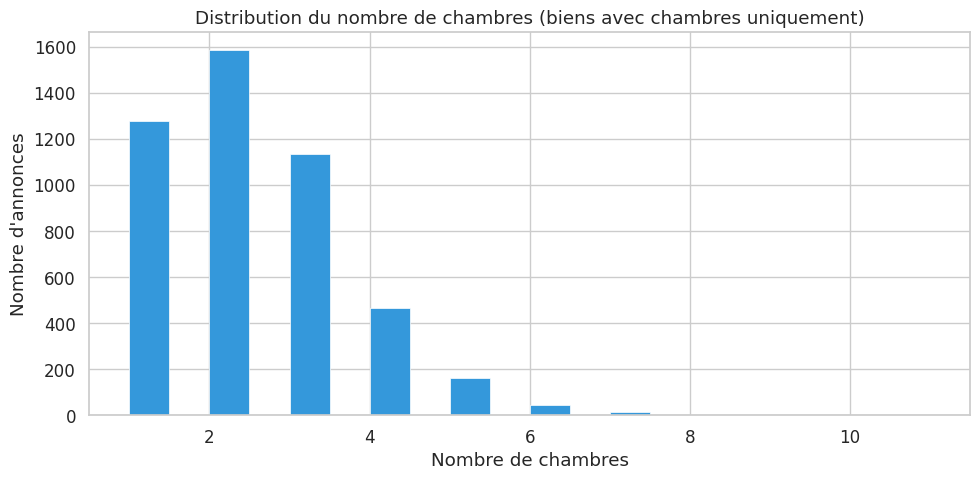

In [21]:
nb_chambres_pd = df.filter(F.col('nb_chambres').isNotNull()).select('nb_chambres').toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(nb_chambres_pd['nb_chambres'], bins=20, color='#3498db', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Nombre de chambres')
ax.set_ylabel("Nombre d'annonces")
ax.set_title('Distribution du nombre de chambres (biens avec chambres uniquement)')
plt.tight_layout()
plt.show()

- La variable nombre de chambres est globalement cohérente. La majorité des biens ont entre 1 et 3 chambres, ce qui est logique. On observe environ 10 % de valeurs manquantes. 
- Ces valeurs nulles concernent surtout les studios et les immeubles, ce qui peut s’expliquer par la nature de ces biens. Les valeurs très élevées, comme 8 ou 11 chambres, sont très rares et devront être vérifiées.
- Pour le modèle, on remplace les valeurs manquantes par 0 pour les studios, puis on supprime les quelques lignes restantes où le nombre de chambres n’est pas renseigné.

In [22]:
avant_suppresion = df.count()
df = df.filter(F.col('nb_chambres').isNotNull())
print(f"Avant : {avant_suppresion} | Après : {df.count()} | Supprimées : {avant_suppresion- df.count()}")

Avant : 5209 | Après : 4695 | Supprimées : 514


In [23]:
df.groupBy('type_bien').agg(F.count('*').alias('total'), F.sum(F.when(F.col('nb_chambres').isNull(), 1).otherwise(0)).alias('nb_null')).orderBy(F.desc('nb_null')).show(truncate=False)

+-----------+-----+-------+
|type_bien  |total|nb_null|
+-----------+-----+-------+
|appartement|3639 |0      |
|duplex     |181  |0      |
|maison     |778  |0      |
|loft       |38   |0      |
|studio     |53   |0      |
|immeuble   |6    |0      |
+-----------+-----+-------+



## Preparation des features

In [24]:
df = df.withColumn('nb_pieces', F.col('nb_pieces').cast('double').cast('integer'))

In [25]:

TOP50_MOTS = ['appartement', 'situ', 'tage', 'maison', 'quartier', 'rue', 'immeuble', 'calme', 'chambres', 'terrasse', 'cuisine', 'salle', 'lumineux', 'ascenseur', 'balcon', 'jardin', 'saint', 'vie', 'proximit', 'jour', 'place', 'vue', 'exclusivit', 'dernier', 'parking', 'vendre', 'coeur', 'commerces', 'garage', 'proche', 'duplex', 'cave', 'recherch', 'studio', 'entr', 'eau', 'copropri', 'offre', 'rement', 'immobilier', 'nov', 'sejour', 'espace', 'beau', 'entier', 'calme', 'sud', 'expo', 'risques', 'geo']

for mot in TOP50_MOTS:
    df = df.withColumn('nlp_' + mot, F.when(F.lower(F.col('description')).contains(mot), 1.0).otherwise(0.0))

In [26]:
print(f'Colonnes NLP ajoutées : {len(TOP50_MOTS)}')
print(f'Total colonnes : {len(df.columns)}')

Colonnes NLP ajoutées : 50
Total colonnes : 61


## Pipeline 

In [27]:
indexer_ville = StringIndexer(inputCol='ville', outputCol='ville_index', handleInvalid='keep')
indexer_type  = StringIndexer(inputCol='type_bien', outputCol='type_index', handleInvalid='keep')
encoder_ville = OneHotEncoder(inputCol='ville_index', outputCol='ville_vecteur')
encoder_type  = OneHotEncoder(inputCol='type_index', outputCol='type_vecteur')

In [28]:
cols_nlp      = ['nlp_' + mot for mot in TOP50_MOTS]
cols_features = ['surface', 'nb_pieces', 'nb_chambres', 'ville_vecteur', 'type_vecteur'] + cols_nlp
assembler     = VectorAssembler(inputCols=cols_features, outputCol='features', handleInvalid='keep')

In [29]:
eval_rmse = RegressionEvaluator(labelCol='prix', predictionCol='prediction', metricName='rmse')
eval_mae  = RegressionEvaluator(labelCol='prix', predictionCol='prediction', metricName='mae')
eval_r2   = RegressionEvaluator(labelCol='prix', predictionCol='prediction', metricName='r2')

In [30]:
train, test = df.randomSplit([0.8, 0.2], seed=42)
print(f'Train : {train.count()} lignes | Test : {test.count()} lignes')
print(f'Nombre de features : {len(cols_features)}')

Train : 3815 lignes | Test : 880 lignes
Nombre de features : 55


# Régression 

## Entrainement des trois modeles de regression 

In [31]:
# Régression Linéaire
lr = LinearRegression(featuresCol='features', labelCol='prix', maxIter=100)
pipeline_lr = Pipeline(stages=[indexer_ville, indexer_type, encoder_ville, encoder_type, assembler, lr])
modele_lr   = pipeline_lr.fit(train)
preds_lr    = modele_lr.transform(test)
rmse_lr, mae_lr, r2_lr = eval_rmse.evaluate(preds_lr), eval_mae.evaluate(preds_lr), eval_r2.evaluate(preds_lr)
print(f'Régression Linéaire — RMSE : {rmse_lr:,.0f} € | MAE : {mae_lr:,.0f} € | R² : {r2_lr:.4f}')

Régression Linéaire — RMSE : 277,014 € | MAE : 187,190 € | R² : 0.5011


In [32]:
# Random Forest
rf = RandomForestRegressor(featuresCol='features', labelCol='prix', numTrees=50, maxDepth=8, seed=42)
pipeline_rf = Pipeline(stages=[indexer_ville, indexer_type, encoder_ville, encoder_type, assembler, rf])
modele_rf   = pipeline_rf.fit(train)
preds_rf    = modele_rf.transform(test)
rmse_rf, mae_rf, r2_rf = eval_rmse.evaluate(preds_rf), eval_mae.evaluate(preds_rf), eval_r2.evaluate(preds_rf)
print(f'Random Forest      — RMSE : {rmse_rf:,.0f} € | MAE : {mae_rf:,.0f} € | R² : {r2_rf:.4f}')

Random Forest      — RMSE : 211,828 € | MAE : 109,954 € | R² : 0.7083


In [33]:
# GBT
gbt = GBTRegressor(featuresCol='features', labelCol='prix', maxIter=50, maxDepth=5, seed=42)
pipeline_gbt = Pipeline(stages=[indexer_ville, indexer_type, encoder_ville, encoder_type, assembler, gbt])
modele_gbt   = pipeline_gbt.fit(train)
preds_gbt    = modele_gbt.transform(test)
rmse_gbt, mae_gbt, r2_gbt = eval_rmse.evaluate(preds_gbt), eval_mae.evaluate(preds_gbt), eval_r2.evaluate(preds_gbt)
print(f'GBT                — RMSE : {rmse_gbt:,.0f} € | MAE : {mae_gbt:,.0f} € | R² : {r2_gbt:.4f}')

GBT                — RMSE : 194,294 € | MAE : 105,593 € | R² : 0.7546


## Comparaison des modeles 

In [34]:
resultats_regression = pd.DataFrame({
    'Modèle'  : ['Régression Linéaire', 'Random Forest', 'GBT'],
    'RMSE (€)': [round(rmse_lr, 0), round(rmse_rf, 0), round(rmse_gbt, 0)],
    'MAE (€)' : [round(mae_lr, 0), round(mae_rf, 0), round(mae_gbt, 0)],
    'R²'      : [round(r2_lr, 4), round(r2_rf, 4), round(r2_gbt, 4)]
}).sort_values('R²', ascending=False).reset_index(drop=True)

In [35]:
print(resultats_regression.to_string(index=False))

             Modèle  RMSE (€)  MAE (€)     R²
                GBT  194294.0 105593.0 0.7546
      Random Forest  211828.0 109954.0 0.7083
Régression Linéaire  277014.0 187190.0 0.5011


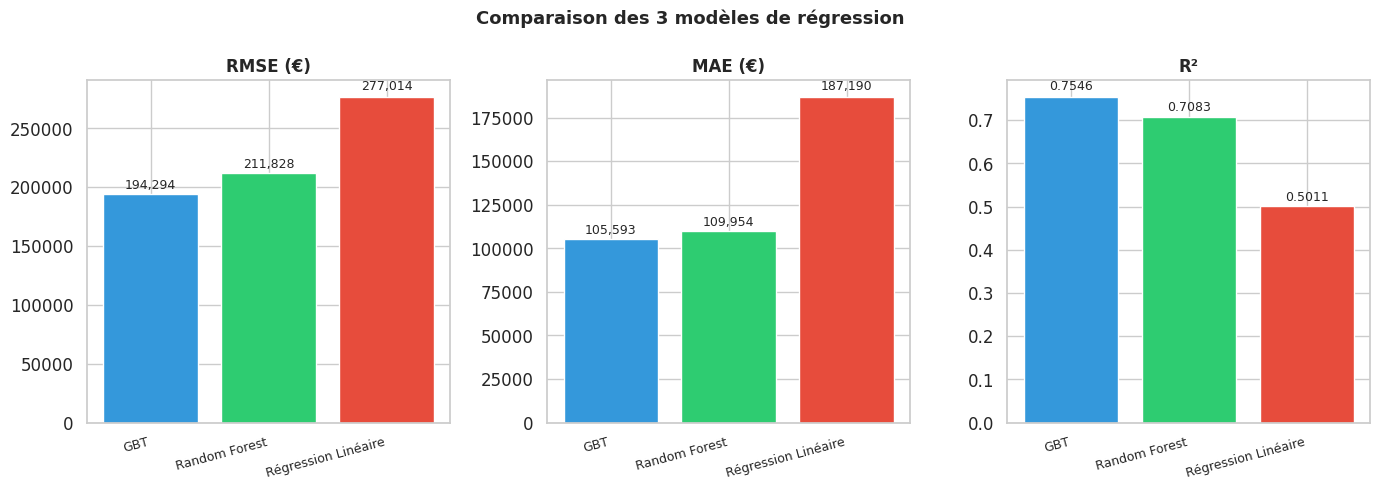

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
modeles = resultats_regression['Modèle']
colors  = ['#3498db', '#2ecc71', '#e74c3c']
for ax, metric in zip(axes, ['RMSE (€)', 'MAE (€)', 'R²']):
    bars = ax.bar(modeles, resultats_regression[metric], color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticklabels(modeles, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, resultats_regression[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01, f'{val:,.0f}' if metric != 'R²' else f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparaison des 3 modèles de régression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- Les résultats montrent que le meilleur modèle de régression est le GBT. C’est lui qui a les erreurs les plus faibles, avec un RMSE de 194 294 € et un MAE de 105 593 €, et c’est aussi lui qui explique le mieux le prix des biens avec un R² de 0,7546. Cela veut dire qu’il arrive à expliquer environ 75 % de la variation des prix.

- Le modèle Random Forest donne aussi des résultats corrects, mais il est un peu moins bon que le GBT. Ses erreurs sont un peu plus élevées, avec un RMSE de 211 828 € et un MAE de 109 954 €, et son R² est de 0,7083. Il reste donc performant, mais légèrement en dessous du GBT.

- La régression linéaire est le modèle le moins bon des trois. Elle a les erreurs les plus élevées, avec un RMSE de 277 014 € et un MAE de 187 190 €, et son R² de 0,5011 montre qu’elle explique beaucoup moins bien le prix. Cela veut dire que la relation entre les variables et le prix est sans doute trop complexe pour un modèle linéaire simple.

- Au final, on retient donc le GBT comme meilleur modèle de régression pour ce projet, car c’est celui qui prédit le mieux le prix des biens immobiliers parmi les trois modèles testés.

In [37]:
meilleur_preds = preds_gbt

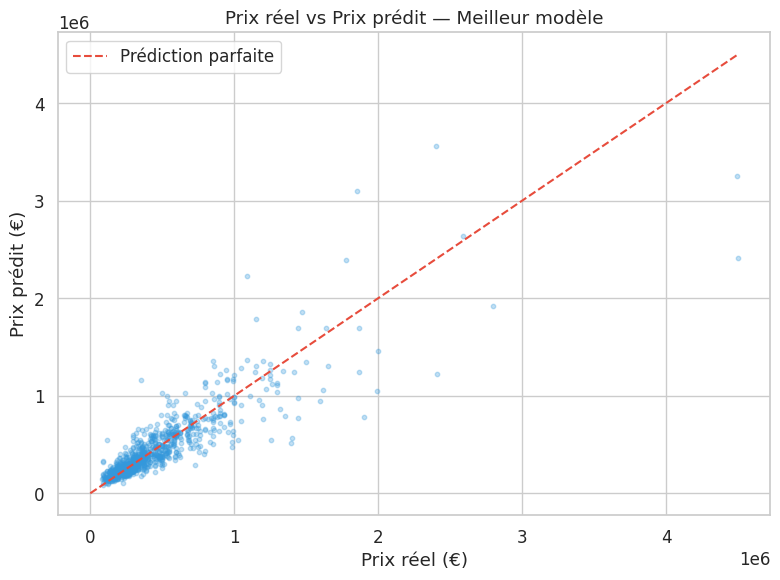

In [38]:
preds_pd = meilleur_preds.select('prix', 'prediction').toPandas()
fig, ax  = plt.subplots(figsize=(8, 6))
ax.scatter(preds_pd['prix'], preds_pd['prediction'], alpha=0.3, color='#3498db', s=10)
max_val  = max(preds_pd['prix'].max(), preds_pd['prediction'].max())
ax.plot([0, max_val], [0, max_val], color='#e74c3c', linestyle='--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Prix réel (€)')
ax.set_ylabel('Prix prédit (€)')
ax.set_title('Prix réel vs Prix prédit — Meilleur modèle')
ax.legend()
plt.tight_layout()
plt.show()

Nous comparons le prix réel et le prix prédit par le modèle.
On voit que beaucoup de points sont proches de la ligne rouge, donc les prédictions sont souvent bonnes.
On voit aussi que le modèle est moins précis pour les biens les plus chers.

In [39]:
# Importance des variables (meilleur modèle : GBT)
gbt_model = modele_gbt.stages[-1]
importances = gbt_model.featureImportances.toArray()


meta = modele_gbt.transform(train.limit(1)).schema['features'].metadata['ml_attr']['attrs']

feature_infos = []
for group in meta.values():
    feature_infos.extend(group)

feature_infos = sorted(feature_infos, key=lambda x: x['idx'])
feature_names = [x['name'] for x in feature_infos]


fi_pd = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

fi_pd = fi_pd[fi_pd['Importance'] > 0].sort_values('Importance', ascending=False).head(20)


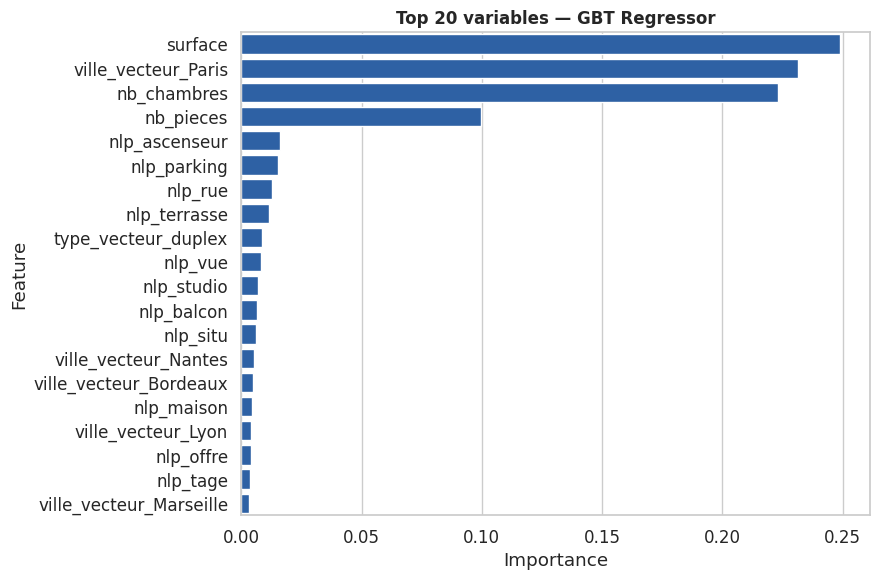

In [40]:
# Graphique
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=fi_pd, x='Importance', y='Feature', color='#1a5eb8', ax=ax)
ax.set_title('Top 20 variables — GBT Regressor', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

- Nous voyons que la surface, la ville de Paris, le nombre de chambres et le nombre de pièces sont les variables les plus importantes du modèle. Les autres variables, surtout les mots NLP, ont une importance plus faible. Cela montre qu’il faudrait sûrement plus de variables pour mieux prédire les biens les plus chers, qui semblent plus difficiles à estimer avec les informations actuelles.

# Classfication

## COnstruction de la cible

In [42]:
df_clf = df.filter(F.col('type_bien') != 'immeuble')

In [43]:
mediane_ville = df_clf.groupBy('ville').agg(F.percentile_approx('prix_m2', 0.5).alias('mediane_ville'))
df_clf = df_clf.join(mediane_ville, on='ville', how='left')

In [44]:

df_clf = df_clf.withColumn('is_cher',
    F.when(F.col('prix_m2') >= F.col('mediane_ville') * 1.10, 1)
     .when(F.col('prix_m2') <= F.col('mediane_ville') * 0.90, 0)
     .otherwise(None)
)

In [45]:
avant = df_clf.count()
df_clf = df_clf.filter(F.col('is_cher').isNotNull()).drop('mediane_ville')
apres = df_clf.count()

In [48]:
print(f'Avant : {avant} | Après retrait zone neutre : {apres} | Retirées : {avant - apres}')
print('\nDistribution is_cher :')
df_clf.groupBy('is_cher').count().orderBy('is_cher').show()

Avant : 4689 | Après retrait zone neutre : 3155 | Retirées : 1534

Distribution is_cher :
+-------+-----+
|is_cher|count|
+-------+-----+
|      0| 1545|
|      1| 1610|
+-------+-----+



In [49]:
print('\nDistribution is_cher par ville :')
df_clf.groupBy('ville', 'is_cher').count().orderBy('ville', 'is_cher').show()


Distribution is_cher par ville :
+---------+-------+-----+
|    ville|is_cher|count|
+---------+-------+-----+
| Bordeaux|      0|  300|
| Bordeaux|      1|  322|
|     Lyon|      0|  314|
|     Lyon|      1|  320|
|Marseille|      0|  358|
|Marseille|      1|  366|
|   Nantes|      0|  304|
|   Nantes|      1|  328|
|    Paris|      0|  269|
|    Paris|      1|  274|
+---------+-------+-----+



# Decoupage et entrainement

In [50]:
indexer_ville_clf = StringIndexer(inputCol='ville', outputCol='ville_index', handleInvalid='keep')
indexer_type_clf  = StringIndexer(inputCol='type_bien', outputCol='type_index', handleInvalid='keep')
encoder_ville_clf = OneHotEncoder(inputCol='ville_index', outputCol='ville_vecteur')
encoder_type_clf  = OneHotEncoder(inputCol='type_index', outputCol='type_vecteur')

In [51]:
cols_features_clf = ['surface', 'nb_pieces', 'nb_chambres', 'ville_vecteur', 'type_vecteur'] + cols_nlp
assembler_clf     = VectorAssembler(inputCols=cols_features_clf, outputCol='features', handleInvalid='keep')

In [54]:
eval_auc = BinaryClassificationEvaluator(labelCol='is_cher', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
eval_acc = MulticlassClassificationEvaluator(labelCol='is_cher', predictionCol='prediction', metricName='accuracy')
eval_f1  = MulticlassClassificationEvaluator(labelCol='is_cher', predictionCol='prediction', metricName='f1')

train_clf, test_clf = df_clf.randomSplit([0.8, 0.2], seed=42)
print(f'Train : {train_clf.count()} lignes | Test : {test_clf.count()} lignes')
print(f'Taux is_cher train : {train_clf.filter(F.col("is_cher") == 1).count() / train_clf.count():.3f}')
print(f'Taux is_cher test  : {test_clf.filter(F.col("is_cher") == 1).count() / test_clf.count():.3f}')

Train : 2571 lignes | Test : 584 lignes
Taux is_cher train : 0.513
Taux is_cher test  : 0.500


In [55]:
# Régression Logistique
log_reg      = LogisticRegression(featuresCol='features', labelCol='is_cher', maxIter=100)
pipeline_log = Pipeline(stages=[indexer_ville_clf, indexer_type_clf, encoder_ville_clf, encoder_type_clf, assembler_clf, log_reg])
modele_log   = pipeline_log.fit(train_clf)
preds_log    = modele_log.transform(test_clf)
auc_log, acc_log, f1_log = eval_auc.evaluate(preds_log), eval_acc.evaluate(preds_log), eval_f1.evaluate(preds_log)
print(f'Régression Logistique — AUC : {auc_log:.4f} | Accuracy : {acc_log:.4f} | F1 : {f1_log:.4f}')

Régression Logistique — AUC : 0.6637 | Accuracy : 0.6353 | F1 : 0.6345


- La régression logistique donne des résultats moyens. L’AUC de 0,6637 montre que le modèle arrive un peu à distinguer les biens chers des biens non chers, mais ce n’est pas très fort.
L’accuracy de 0,6353 et le F1-score de 0,6345 montrent aussi que le modèle classe correctement environ 6 biens sur 10.
Donc, ce modèle fonctionne un peu, mais il reste encore limité pour bien séparer les deux classes.

In [56]:
# Random Forest
rf_clf          = RandomForestClassifier(featuresCol='features', labelCol='is_cher', numTrees=50, maxDepth=8, seed=42)
pipeline_rf_clf = Pipeline(stages=[indexer_ville_clf, indexer_type_clf, encoder_ville_clf, encoder_type_clf, assembler_clf, rf_clf])
modele_rf_clf   = pipeline_rf_clf.fit(train_clf)
preds_rf_clf    = modele_rf_clf.transform(test_clf)
auc_rf, acc_rf, f1_rf = eval_auc.evaluate(preds_rf_clf), eval_acc.evaluate(preds_rf_clf), eval_f1.evaluate(preds_rf_clf)
print(f'Random Forest         — AUC : {auc_rf:.4f} | Accuracy : {acc_rf:.4f} | F1 : {f1_rf:.4f}')


Random Forest         — AUC : 0.6870 | Accuracy : 0.6267 | F1 : 0.6265


- Le modèle Random Forest donne aussi des résultats moyens. L’AUC de 0,6870 montre qu’il distingue un peu mieux les biens chers et non chers que la régression logistique.
En revanche, l’accuracy de 0,6267 et le F1-score de 0,6265 restent proches de 0,63, donc le modèle classe correctement un peu plus de 6 biens sur 10.
Globalement, ce modèle est légèrement meilleur pour séparer les classes, mais ses performances restent encore limitées.

In [58]:
# GBT
gbt_clf          = GBTClassifier(featuresCol='features', labelCol='is_cher', maxIter=50, maxDepth=5, seed=42)
pipeline_gbt_clf = Pipeline(stages=[indexer_ville_clf, indexer_type_clf, encoder_ville_clf, encoder_type_clf, assembler_clf, gbt_clf])
modele_gbt_clf   = pipeline_gbt_clf.fit(train_clf)
preds_gbt_clf    = modele_gbt_clf.transform(test_clf)
auc_gbt, acc_gbt, f1_gbt = eval_auc.evaluate(preds_gbt_clf), eval_acc.evaluate(preds_gbt_clf), eval_f1.evaluate(preds_gbt_clf)
print(f'GBT                   — AUC : {auc_gbt:.4f} | Accuracy : {acc_gbt:.4f} | F1 : {f1_gbt:.4f}')

GBT                   — AUC : 0.6978 | Accuracy : 0.6490 | F1 : 0.6489


Le modèle GBT est celui qui donne les meilleurs résultats parmi les trois. L’AUC de 0,6978 montre qu’il distingue un peu mieux les biens chers et non chers.
L’accuracy de 0,6490 et le F1-score de 0,6489 montrent aussi qu’il classe correctement presque 65 % des biens.
Globalement, ce modèle reste moyen, mais il est le plus performant des trois pour cette partie classification.

## Comparaison

               Modèle    AUC  Accuracy     F1
                  GBT 0.6978    0.6490 0.6489
        Random Forest 0.6870    0.6267 0.6265
Régression Logistique 0.6637    0.6353 0.6345


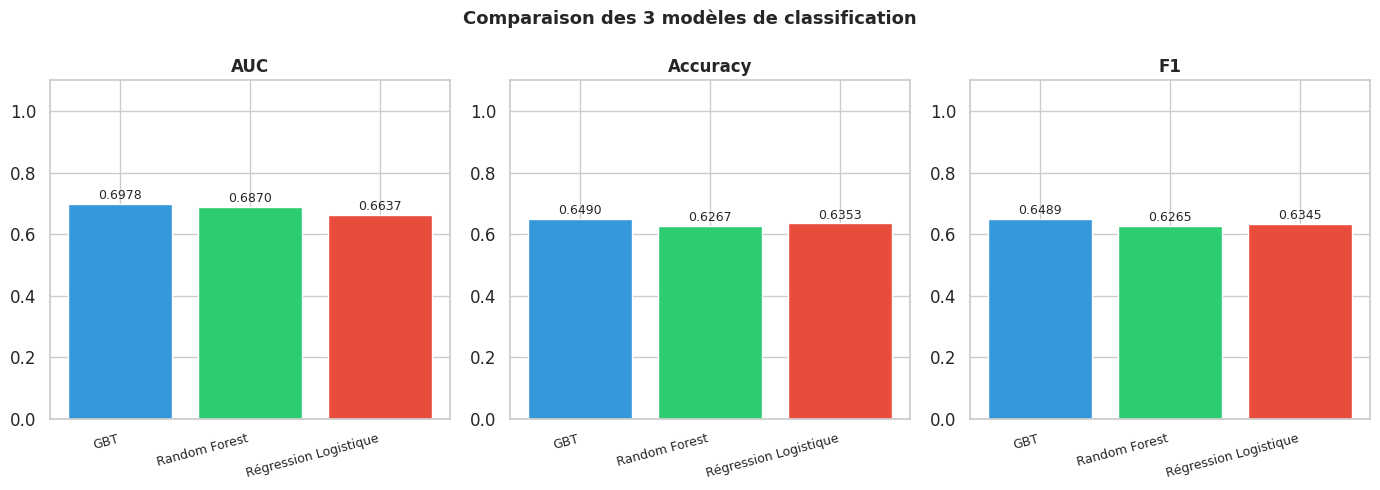

In [59]:
resultats_clf = pd.DataFrame({
    'Modèle'  : ['Régression Logistique', 'Random Forest', 'GBT'],
    'AUC'     : [round(auc_log, 4), round(auc_rf, 4), round(auc_gbt, 4)],
    'Accuracy': [round(acc_log, 4), round(acc_rf, 4), round(acc_gbt, 4)],
    'F1'      : [round(f1_log, 4), round(f1_rf, 4), round(f1_gbt, 4)]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

print(resultats_clf.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric in zip(axes, ['AUC', 'Accuracy', 'F1']):
    bars = ax.bar(resultats_clf['Modèle'], resultats_clf[metric], color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(resultats_clf['Modèle'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, resultats_clf[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparaison des 3 modèles de classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

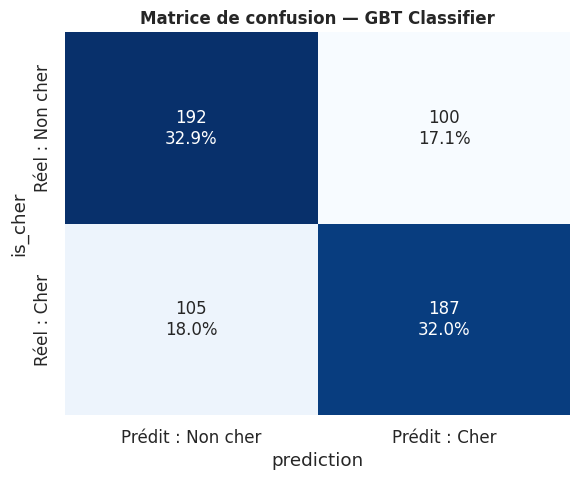

In [63]:
# Matrice de confusion (GBT)
preds_pd = preds_gbt_clf.select('is_cher', 'prediction').toPandas()
cm       = pd.crosstab(preds_pd['is_cher'], preds_pd['prediction'])
total    = len(preds_pd)
annot    = np.array([[f"{v}\n{v/total:.1%}" for v in row] for row in cm.values])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Prédit : Non cher', 'Prédit : Cher'],
            yticklabels=['Réel : Non cher', 'Réel : Cher'],
            annot_kws={'size': 12}, ax=ax)
ax.set_title('Matrice de confusion — GBT Classifier', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


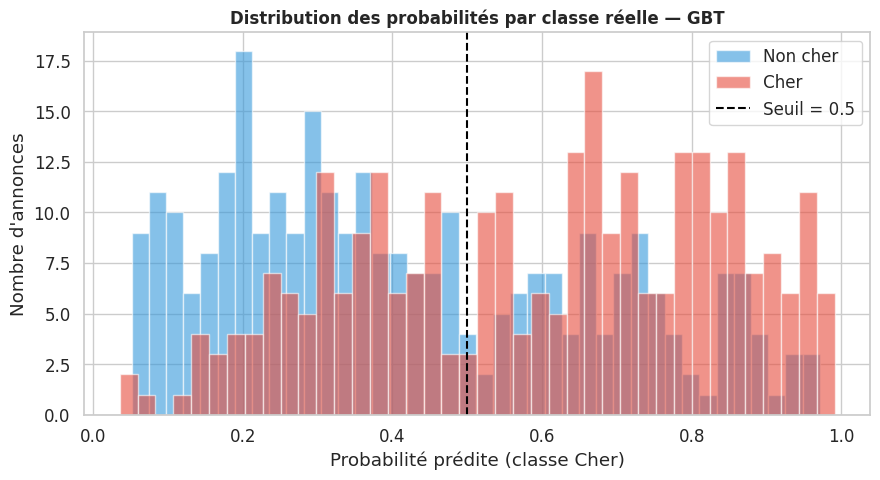

In [61]:
# Distribution des probabilités
proba_pd = preds_gbt_clf.select('is_cher', 'probability').toPandas()
proba_pd['proba_1'] = proba_pd['probability'].apply(lambda x: float(x[1]))

fig, ax = plt.subplots(figsize=(9, 5))
for label, color, name in [(0, '#3498db', 'Non cher'), (1, '#e74c3c', 'Cher')]:
    ax.hist(proba_pd[proba_pd['is_cher'] == label]['proba_1'], bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Seuil = 0.5')
ax.set_xlabel('Probabilité prédite (classe Cher)')
ax.set_ylabel("Nombre d'annonces")
ax.set_title('Distribution des probabilités par classe réelle — GBT', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

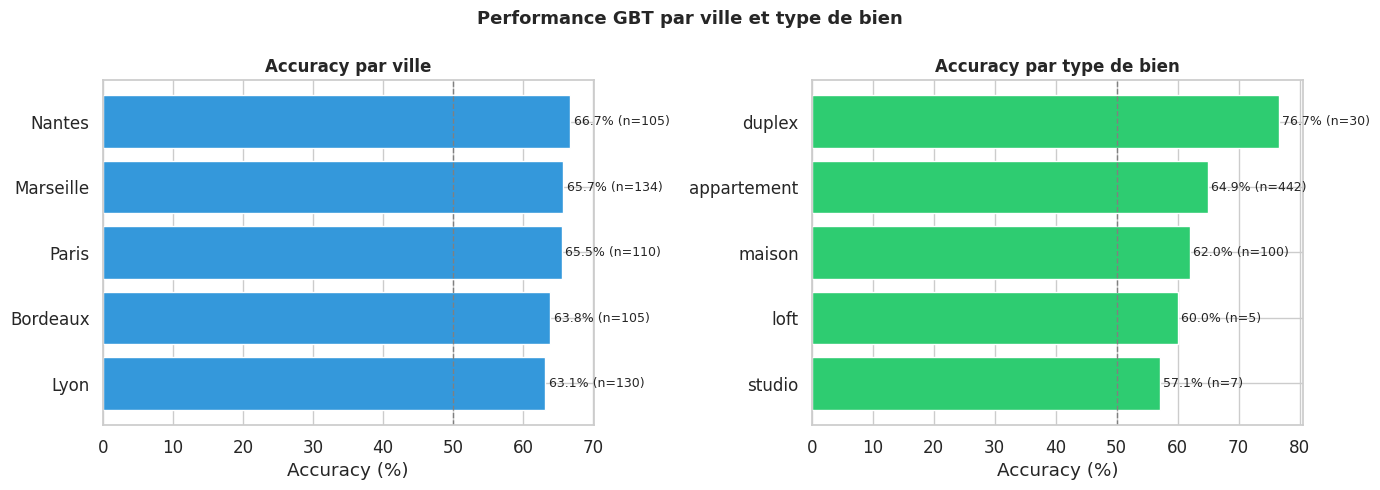

In [62]:
# Accuracy par ville et type_bien
perf_ville_pd = preds_gbt_clf.select('ville', 'is_cher', 'prediction').withColumn('correct', F.when(F.col('is_cher') == F.col('prediction'), 1).otherwise(0)).groupBy('ville').agg(F.count('*').alias('nb'), F.round(F.mean('correct') * 100, 1).alias('accuracy_%')).toPandas().sort_values('accuracy_%', ascending=True)

perf_type_pd = preds_gbt_clf.select('type_bien', 'is_cher', 'prediction').withColumn('correct', F.when(F.col('is_cher') == F.col('prediction'), 1).otherwise(0)).groupBy('type_bien').agg(F.count('*').alias('nb'), F.round(F.mean('correct') * 100, 1).alias('accuracy_%')).toPandas().sort_values('accuracy_%', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(perf_ville_pd['ville'], perf_ville_pd['accuracy_%'], color='#3498db', edgecolor='white')
axes[0].axvline(50, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Accuracy par ville', fontsize=12, fontweight='bold')
for i, (val, nb) in enumerate(zip(perf_ville_pd['accuracy_%'], perf_ville_pd['nb'])):
    axes[0].text(val + 0.5, i, f'{val}% (n={nb})', va='center', fontsize=9)

axes[1].barh(perf_type_pd['type_bien'], perf_type_pd['accuracy_%'], color='#2ecc71', edgecolor='white')
axes[1].axvline(50, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_title('Accuracy par type de bien', fontsize=12, fontweight='bold')
for i, (val, nb) in enumerate(zip(perf_type_pd['accuracy_%'], perf_type_pd['nb'])):
    axes[1].text(val + 0.5, i, f'{val}% (n={nb})', va='center', fontsize=9)

plt.suptitle('Performance GBT par ville et type de bien', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
model = PipelineModel.load("/workspaces/bigdata-immobilier/projet/models/gbt_regression")